In [ ]:
# Настройка путей 
import sys
from pathlib import Path

# Получаем путь к корню проекта: поднимаемся из "Jupyter Notebooks/" на уровень выше
project_root = Path().resolve().parent

# Добавляем корень проекта в sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root added to sys.path: {project_root}")

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from config import RAW_DATA_DIR
from src.db.queries import run_query


In [30]:
plt.rcParams['figure.figsize'] = (10, 5)

In [31]:
# Загрузка данных
df = pd.read_csv(RAW_DATA_DIR / "third_wave_coffee_shop.csv", parse_dates=['datetime', 'sale_date'])

In [32]:
# базовый осмотр
df.head(), df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4943 entries, 0 to 4942
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  4943 non-null   object        
 1   customer_id     4943 non-null   object        
 2   sale_date       4943 non-null   datetime64[ns]
 3   sale_time       4943 non-null   object        
 4   day_of_week     4943 non-null   int64         
 5   day_name        4943 non-null   object        
 6   is_weekend      4943 non-null   bool          
 7   coffee_name     4943 non-null   object        
 8   drink_price     4943 non-null   float64       
 9   total_cost      4943 non-null   float64       
 10  payment_method  4943 non-null   object        
 11  datetime        4943 non-null   datetime64[ns]
 12  time_of_day     4943 non-null   object        
dtypes: bool(1), datetime64[ns](2), float64(2), int64(1), object(7)
memory usage: 468.4+ KB


(  transaction_id customer_id  sale_date sale_time  day_of_week day_name  \
 0        TX_0125   CUST_6596 2025-07-01  08:24:55            2  Tuesday   
 1        TX_0125   CUST_6596 2025-07-01  08:24:55            2  Tuesday   
 2        TX_1977   CUST_4044 2025-07-01  08:42:32            2  Tuesday   
 3        TX_3011   CUST_2256 2025-07-01  08:43:55            2  Tuesday   
 4        TX_3392   CUST_6082 2025-07-01  08:44:55            2  Tuesday   
 
    is_weekend     coffee_name  drink_price  total_cost payment_method  \
 0       False      Cappuccino        320.0       640.0           card   
 1       False      Cappuccino        320.0       640.0           card   
 2       False           Latte        340.0       340.0           card   
 3       False  Latte with add        440.0       440.0           cash   
 4       False  Latte with add        440.0       760.0           card   
 
              datetime time_of_day  
 0 2025-07-01 08:24:55     Morning  
 1 2025-07-01 08:24:55

**Универсальная функция предобработки**

In [33]:
print(df.columns.tolist())

['transaction_id', 'customer_id', 'sale_date', 'sale_time', 'day_of_week', 'day_name', 'is_weekend', 'coffee_name', 'drink_price', 'total_cost', 'payment_method', 'datetime', 'time_of_day']


#### KPI кофейни 

In [34]:
def kpi_summary(df):
    return {
        "Total Revenue": df.groupby("transaction_id")["total_cost"].first().sum(),
        "Transactions": df["transaction_id"].nunique(),
        "Avg Ticket": df.groupby("transaction_id")["drink_price"].sum().mean()
    }

kpi_summary(df)

# С удаление дубликатов "total_cost" в чеке.
# "Total Revenue": df.drop_duplicates("transaction_id")["total_cost"].sum()

{'Total Revenue': np.float64(1668050.0),
 'Transactions': 3547,
 'Avg Ticket': np.float64(470.2706512545813)}

#### Анализ продаж по продуктам (Menu Engineering)

In [35]:
# Топ и анти-топ продуктов
def product_sales(df):
    return (
        df.groupby("coffee_name")
        .agg(
            revenue=("drink_price", "sum"),             # сумма цен всех позиций этого напитка
            quantity=("coffee_name", "count"),          # количество заказанных напитков = число строк
            transactions=("transaction_id", "nunique")  # в скольких чеках встречался
        )
        .sort_values("revenue", ascending=False)
        .reset_index()
    )

top_products = product_sales(df)
top_products.head(10)

,coffee_name,revenue,quantity,transactions
0,Cappuccino,372800.0,1165,1062
1,Latte,354280.0,1042,972
2,Latte with add,326920.0,743,708
3,Batch brew,202560.0,844,795
4,Raf coffee,143640.0,342,338
5,Flat white,113900.0,335,332
6,Warming drinks (tea),106800.0,267,258
7,Espresso,47150.0,205,202


In [36]:
# Добавление месяца и часа (если нужно для группировки)
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['date'] = df['datetime'].dt.date
display(df[['datetime', 'month', 'hour', 'date']].head())

,datetime,month,hour,date
0,2025-07-01 08:24:55,7,8,2025-07-01
1,2025-07-01 08:24:55,7,8,2025-07-01
2,2025-07-01 08:42:32,7,8,2025-07-01
3,2025-07-01 08:43:55,7,8,2025-07-01
4,2025-07-01 08:44:55,7,8,2025-07-01


#### ABC-анализ (фокус на выручку)

*Понимание, на какие 20% напитков приходится 80% выручки → фокус для маркетинга, персонала, закупок.*

In [37]:
def abc_analysis(df):
    # 1. Группируем по напиткам и считаем выручку
    abc = (
        df.groupby("coffee_name")["drink_price"]
          .sum()
          .sort_values(ascending=False)
          .reset_index(name="revenue")  # явно указываем имя агрегированной колонки
    )
    
    # 2. Считаем доли и кумулятивную долю
    abc["revenue_share"] = abc["revenue"] / abc["revenue"].sum()
    abc["cumulative_share"] = abc["revenue_share"].cumsum()
    
    # 3. Присваиваем ABC-классы
    abc["ABC_class"] = np.select(
        condlist=[
            abc["cumulative_share"] <= 0.8,
            abc["cumulative_share"] <= 0.95
        ],
        choicelist=["A", "B"],
        default="C"
    )
    
    return abc

abc_analysis(df).head(10)

,coffee_name,revenue,revenue_share,cumulative_share,ABC_class
0,Cappuccino,372800.0,0.223494,0.223494,A
1,Latte,354280.0,0.212392,0.435886,A
2,Latte with add,326920.0,0.195989,0.631876,A
3,Batch brew,202560.0,0.121435,0.753311,A
4,Raf coffee,143640.0,0.086113,0.839423,B
5,Flat white,113900.0,0.068283,0.907707,B
6,Warming drinks (tea),106800.0,0.064027,0.971733,C
7,Espresso,47150.0,0.028267,1.000000,C


#### Временной анализ (нагрузка и планирование персонала)

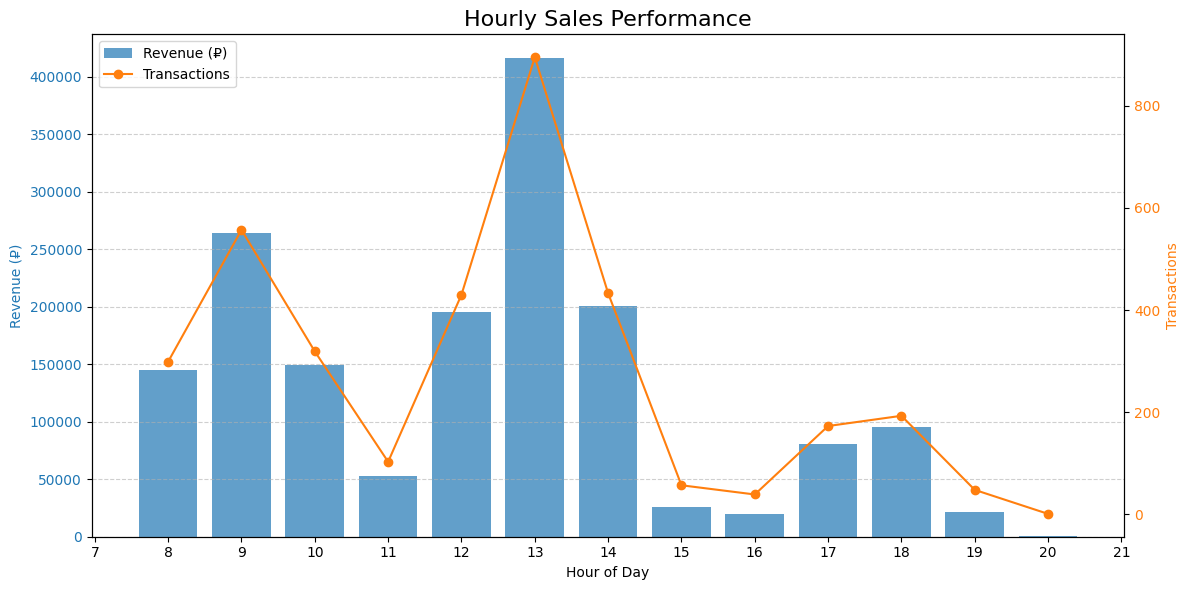

,hour,revenue,transactions,items_sold
0,8,145040.0,299,427
1,9,263820.0,557,792
2,10,149750.0,319,449
3,11,52650.0,103,159
4,12,195630.0,430,572
5,13,416210.0,895,1235
6,14,201050.0,433,593
7,15,25910.0,57,76
8,16,19800.0,39,57
9,17,80740.0,173,242


In [38]:

# 1. Агрегация по часам
hourly_sales = (
    df.groupby("hour", as_index=False)
      .agg(
          revenue=("drink_price", "sum"),
          transactions=("transaction_id", "nunique"),
          items_sold=("coffee_name", "count")  # количество напитков
      )
      .sort_values("hour")  # сортируем от 0 до 23
)

# 2. Визуализация
fig, ax1 = plt.subplots(figsize=(12, 6))

# Столбцы: выручка
color = "tab:blue"
ax1.bar(hourly_sales["hour"], hourly_sales["revenue"], color=color, alpha=0.7, label="Revenue (₽)")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Revenue (₽)", color=color)
ax1.tick_params(axis="y", labelcolor=color)
ax1.set_xticks(range(0, 24))
ax1.grid(axis="y", linestyle="--", alpha=0.6)

# Добавим вторую ось для количества чеков (необязательно, но полезно)
ax2 = ax1.twinx()
color = "tab:orange"
ax2.plot(hourly_sales["hour"], hourly_sales["transactions"], 
         color=color, marker="o", linestyle="-", label="Transactions")
ax2.set_ylabel("Transactions", color=color)
ax2.tick_params(axis="y", labelcolor=color)

# Заголовок и легенда
plt.title("Hourly Sales Performance", fontsize=16)
fig.tight_layout()

# Объединённая легенда
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.show()

# Выведем таблицу для точности
hourly_sales

#### Анализ дней недели


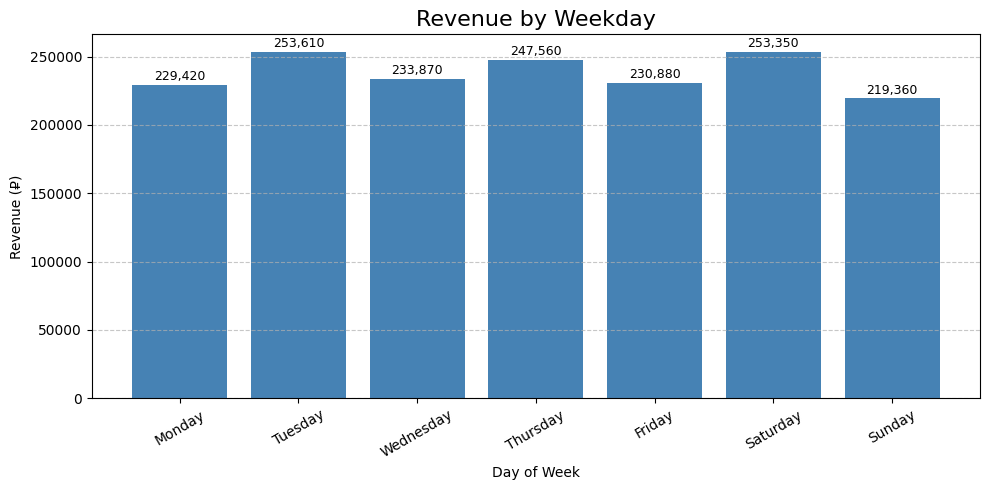

,day_name,revenue,transactions,items,avg_ticket
0,Monday,229420.0,492,675,566.21
1,Tuesday,253610.0,538,755,578.20
2,Wednesday,233870.0,486,695,586.39
3,Thursday,247560.0,524,732,573.17
4,Friday,230880.0,496,698,569.90
5,Saturday,253350.0,517,738,604.21
6,Sunday,219360.0,494,650,536.46


In [55]:
# Гарантируем порядок дней
days_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Агрегация по дням недели
weekday_sales = (
    df.groupby("day_name", as_index=False)
      .agg(revenue=("drink_price", "sum"),
           transactions=("transaction_id", "nunique"),
           items=("coffee_name", "count"),
           avg_ticket=("total_cost", "mean")
      )  
      .round(2)  
      .set_index("day_name")
      .reindex(days_order, fill_value=0)  # ← fill_value=0 — чтобы избежать NaN
      .reset_index()
)

# Визуализация
plt.figure(figsize=(10, 5))
bars = plt.bar(weekday_sales["day_name"], weekday_sales["revenue"], color="steelblue")
plt.title("Revenue by Weekday", fontsize=16)
plt.xlabel("Day of Week")
plt.ylabel("Revenue (₽)")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Добавим подписи значений сверху
for bar, rev in zip(bars, weekday_sales["revenue"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + rev * 0.005,
             f"{rev:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

weekday_sales

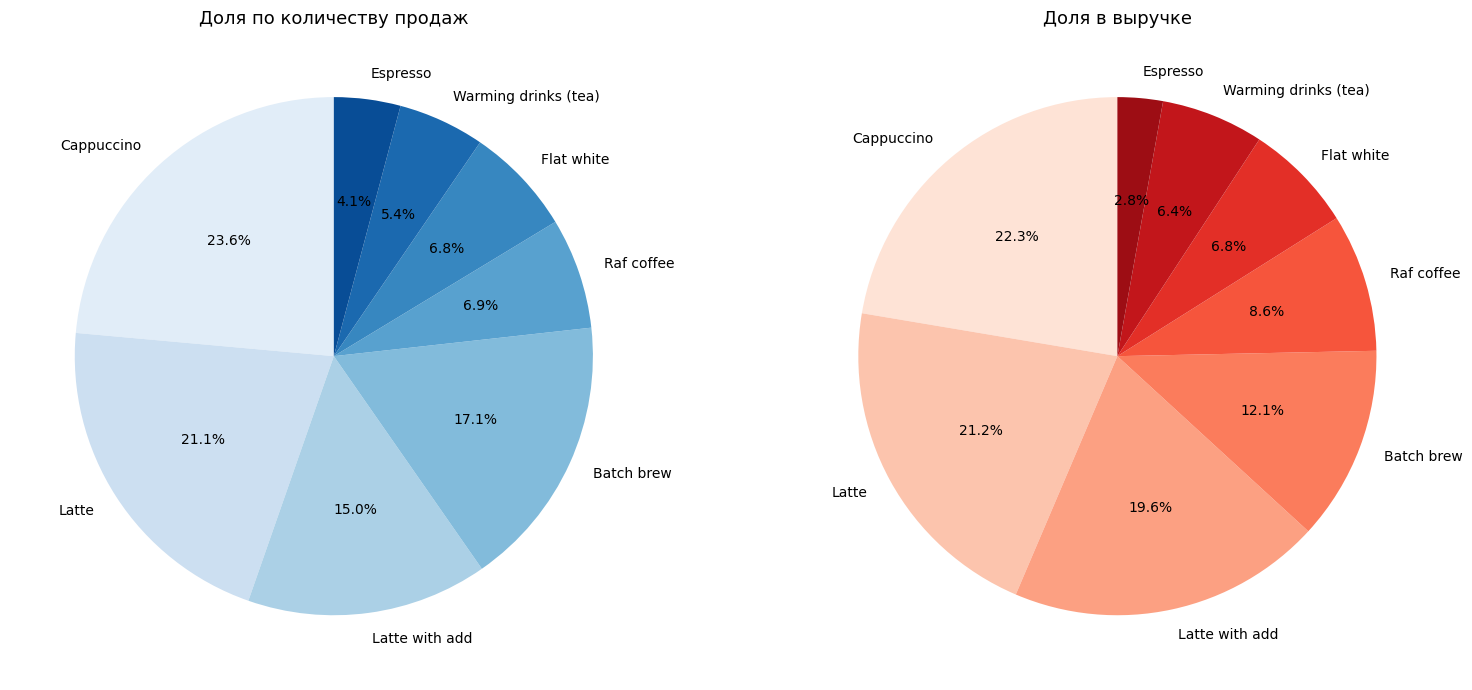

In [60]:
# Подготовка данных
coffee_stats = df.groupby('coffee_name').agg(
    drinks_sold=('coffee_name', 'count'),
    revenue=('drink_price', 'sum')
).round(2).reset_index()

coffee_stats = coffee_stats.sort_values('revenue', ascending=False).head(8)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Доля по количеству
axes[0].pie(
    coffee_stats['drinks_sold'],
    labels=coffee_stats['coffee_name'],
    autopct='%1.1f%%',
    colors=sns.color_palette("Blues", len(coffee_stats)),
    startangle=90
)
axes[0].set_title('Доля по количеству продаж', fontsize=13)

# 2. Доля по выручке
axes[1].pie(
    coffee_stats['revenue'],
    labels=coffee_stats['coffee_name'],
    autopct='%1.1f%%',
    colors=sns.color_palette("Reds", len(coffee_stats)),
    startangle=90
)
axes[1].set_title('Доля в выручке', fontsize=13)

plt.tight_layout()
plt.show()